# DATA266 Lab 1 - Task 1
## GPT-style character-level language model, built from scratch (zohebw)

TinyStories · no `nn.Transformer*`, no `nn.MultiheadAttention`, no fused scaled-dot-product attention.

This notebook documents the completed run `t1_baseline_20260919-232507`. Training itself is run
from the command line (`src/train.py --config configs/gpt_baseline.yaml`) so that every run is
config-driven and logged; this notebook loads that run's artifacts and shows the results.

In [1]:
import json, sys
from pathlib import Path
def _find_root(start=None):
    # Walk up to the repo root (the directory holding common/ and requirements.txt)
    # so the notebook runs from anywhere - no hard-coded personal paths (workplan 5).
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand/'common'/'config.py').exists() and (cand/'requirements.txt').exists():
            return cand
    raise RuntimeError('repo root not found from %s' % p)
ROOT = _find_root()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT/'task1_llm/zoheb_waghu/src'))
import torch, numpy as np, pandas as pd
from common.config import load_config
RUN = 't1_baseline_20260928-151435'
MEMBER = ROOT/'task1_llm/zoheb_waghu'
cfg = load_config(MEMBER/'configs/gpt_baseline.yaml')
print('torch', torch.__version__, '| mps', torch.backends.mps.is_available())
print('run', RUN)

torch 2.5.1 | mps True
run t1_baseline_20260928-151435


## 1. Configuration

Every hyperparameter comes from the YAML - nothing is hard-coded here.

In [2]:
import yaml
print(yaml.safe_dump({k: v for k, v in cfg.items() if k in ('run','data','model','train','generate','eval')},
                     sort_keys=False, default_flow_style=False))

run:
  tag: t1_baseline
  member: zoheb_waghu
  seed: 1337
  device: auto
data:
  dataset: roneneldan/TinyStories
  split_source: train
  pool_path: /Users/zohebw/Desktop/DATA 266/data266-lab1/task1_llm/data/tinystories_raw.txt
  train_sequences: 100000
  val_sequences: 10000
  block_size: 256
  stride: 256
  member_offset_chars: 34000000
  vocab_from: train_only
  cache_dir: /Users/zohebw/Desktop/DATA 266/data266-lab1/task1_llm/zoheb_waghu/data_processed
model:
  n_layer: 4
  n_head: 4
  n_embd: 256
  dropout: 0.1
  pos_embedding: learned
  tie_weights: false
  bias: true
train:
  epochs: 10
  batch_size: 32
  optimizer: adamw
  lr: 0.0003
  min_lr: 3.0e-05
  betas:
  - 0.9
  - 0.95
  weight_decay: 0.1
  grad_clip: 1.0
  warmup_steps: 1000
  schedule: cosine
  eval_interval_steps: 500
  log_interval_steps: 100
generate:
  prompts:
  - Once upon a time
  - The little girl
  - Tom and Jane went
  max_new_tokens: 400
  strategies:
  - name: greedy
  - name: temperature
    temperature: 0

## 2. Data preprocessing (5 marks)

Spec 1.1 asks for "training (100K) and validation (10K)". The team reads those counts as
**sequences**, so at `block_size` 256 with non-overlapping windows that is ~25.6M training
characters and ~2.56M validation characters - not 100K/10K characters.

`char_to_idx` / `idx_to_char` are built from the **training split only**; targets are inputs
shifted right by one.

**Each member creates their own split.** Both members read the same canonical download,
`task1_llm/data/tinystories_raw.txt`, at different `member_offset_chars`, so the two training
slices are disjoint: shreya_akotiya reads chars [0, 34M), mine starts at 34M.

In [3]:
stats = json.loads((MEMBER/'data_processed/stats.json').read_text())
print('sequences -> characters:')
print('  train: {train_sequences:,} seq x stride {stride} = {train_chars:,} chars'.format(**stats))
print('  val:   {val_sequences:,} seq x stride {stride} = {val_chars:,} chars'.format(**stats))
print('  my slice starts at char {member_offset_chars:,} of the shared pool'.format(**stats))
print()
vocab_json = json.loads((MEMBER/'data_processed/vocab.json').read_text())['char_to_idx']
print(json.dumps(stats, indent=2))
print('\nvocabulary (%d chars):' % len(vocab_json))
print(''.join(sorted(c for c in vocab_json if c.isprintable()))[:120])

sequences -> characters:
  train: 100,000 seq x stride 256 = 25,600,001 chars
  val:   10,000 seq x stride 256 = 2,559,763 chars
  my slice starts at char 34,000,000 of the shared pool

{
  "train_sequences": 100000,
  "val_sequences": 10000,
  "stride": 256,
  "member_offset_chars": 34000000,
  "train_chars": 25600001,
  "val_chars": 2559763,
  "vocab_size": 97,
  "val_oov_chars": 0
}

vocabulary (97 chars):
 !"$'()*,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ]_`abcdefghijklmnopqrstuvwxyz´éñö–—‘’“”…


In [4]:
train_ids = np.load(MEMBER/'data_processed/train_ids.npy')
itos = {i: c for c, i in vocab_json.items()}
decode = lambda a: ''.join(itos[int(i)] for i in a)
x = train_ids[:64]; y = train_ids[1:65]          # target = input shifted right by one
print('input :', repr(decode(x)))
print('target:', repr(decode(y)))
print('\nshift verified:', bool((train_ids[1:65] == y).all()))

input : 'Once upon a time, there was a little boy named Timmy. Timmy love'
target: 'nce upon a time, there was a little boy named Timmy. Timmy loved'

shift verified: True


## 3. Model (15 marks)

Implemented in [src/model.py](src/model.py). Attention, causal masking, head split/merge,
layer norm, FFN, residuals and both embedding tables are all written out explicitly.

In [5]:
from model import GPT, CausalSelfAttention
import inspect
print(inspect.getsource(CausalSelfAttention.forward))

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        # (B, T, C) -> (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * self.scale          # (B, nh, T, T)
        att = att.masked_fill(~self.causal_mask[:, :, :T, :T], float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        y = att @ v                                            # (B, nh, T, hd)
        y = y.transpose(1, 2).contiguous().view(B, T, C)       # merge heads
        y = self.resid_dropout(self.proj(y))
        return (y, att) if return_attn else y



In [6]:
m = cfg['model']
model = GPT(stats['vocab_size'], m['n_layer'], m['n_head'], m['n_embd'],
            cfg['data']['block_size'], m['dropout'], m['bias'], m['tie_weights'])
ckpt = torch.load(MEMBER/f'checkpoints/{RUN}_best.pt', map_location='cpu', weights_only=False)
model.load_state_dict(ckpt['model']); model.eval()
print('parameters:', f"{model.num_params():,}")
print('best epoch:', ckpt['epoch'], '| val loss:', round(ckpt['val_loss'], 5))
model

parameters: 3,274,752
best epoch: 9 | val loss: 0.70286


GPT(
  (tok_emb): Embedding(97, 256)
  (pos_emb): Embedding(256, 256)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=256, out_features=97,

### 3.1 Causal mask verified behaviourally

Not a picture of the mask - a perturbation test. Change the token at position *j* and confirm the
logits at every position *i < j* are **bit-identical**, while positions at and after *j* move.

In [7]:
from evaluate import causal_mask_probe
probe = causal_mask_probe(model, stats['vocab_size'], cfg['data']['block_size'], torch.device('cpu'))
print(json.dumps(probe, indent=2))
assert probe['passed'], 'causal mask leaks future information'
print('\nPASS: logits before position j are unchanged (delta = %.1f); positions from j move (delta = %.4f)'
      % (probe['max_logit_delta_before_j'], probe['min_logit_delta_from_j']))

{
  "probe_position": 128,
  "max_logit_delta_before_j": 0.0,
  "min_logit_delta_from_j": 5.243642807006836,
  "passed": true
}

PASS: logits before position j are unchanged (delta = 0.0); positions from j move (delta = 5.2436)


## 4. Training and loss curves (8 marks)

12 epochs, cross-entropy, 150-step warm-up then cosine decay.

In [8]:
hist = json.loads((MEMBER/f'outputs/history_{RUN}.json').read_text())
df = pd.DataFrame(hist['history'])
df['gap'] = df['loss'] - df['train_loss']
df[['epoch','train_loss','loss','perplexity','bits_per_char','top1_next_char_acc','gap']].round(4)

,epoch,train_loss,loss,perplexity,bits_per_char,top1_next_char_acc,gap
0,0,1.6363,1.0205,2.7745,1.4722,0.6812,-0.6158
1,1,1.0112,0.8813,2.4141,1.2715,0.7222,-0.1299
2,2,0.9097,0.8229,2.2772,1.1873,0.7404,-0.0868
3,3,0.8578,0.7847,2.1918,1.1321,0.7524,-0.0731
4,4,0.8216,0.7566,2.1310,1.0915,0.7613,-0.0650
5,5,0.7953,0.7368,2.0892,1.0630,0.7670,-0.0585
6,6,0.7780,0.7248,2.0643,1.0456,0.7706,-0.0532
7,7,0.7649,0.7146,2.0434,1.0310,0.7738,-0.0502
8,8,0.7548,0.7070,2.0280,1.0200,0.7762,-0.0478
9,9,0.7497,0.7029,2.0195,1.0140,0.7772,-0.0468


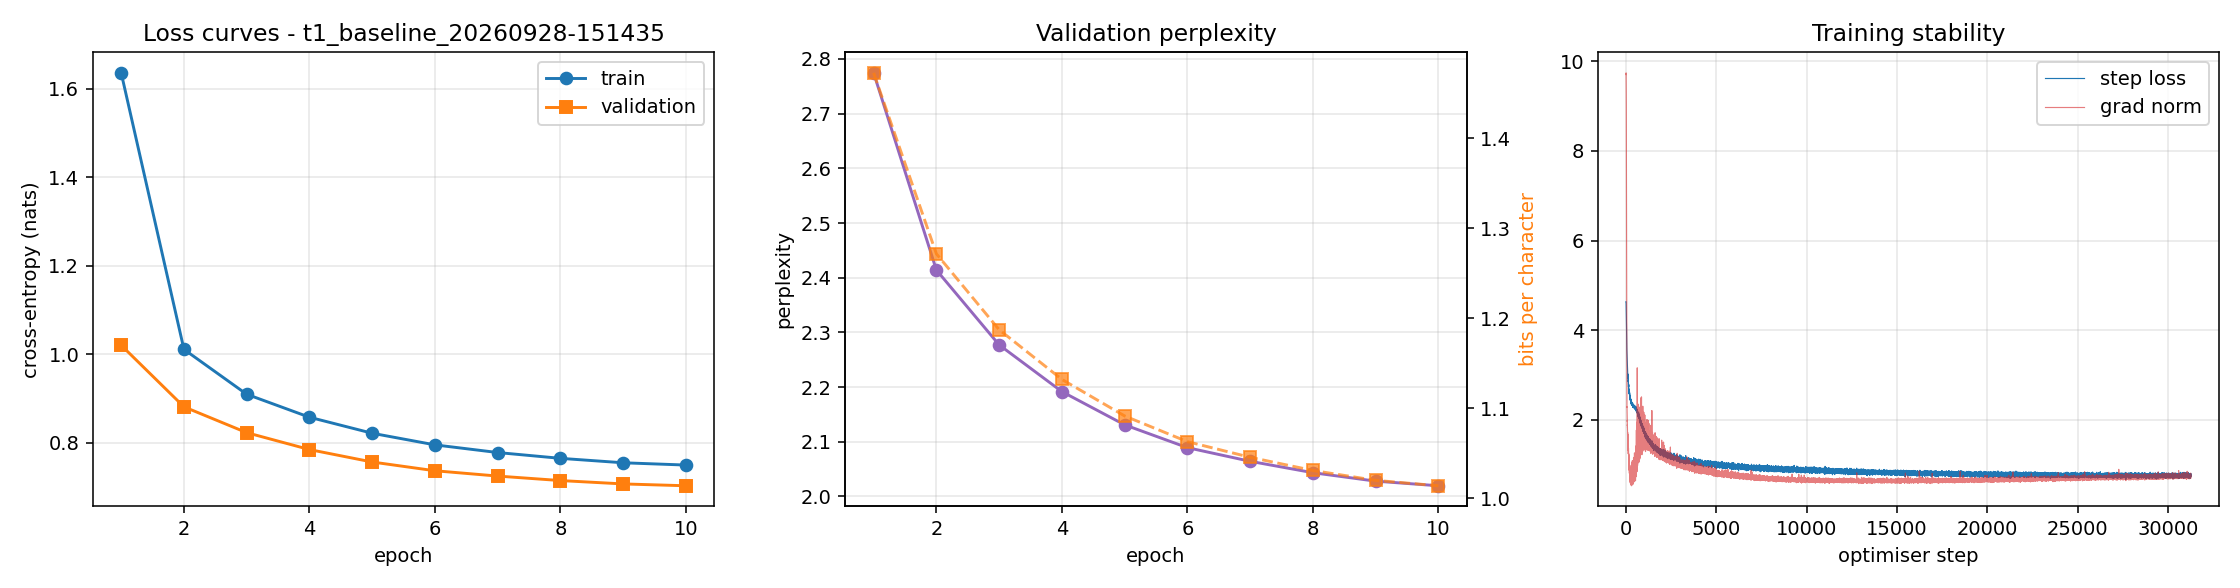

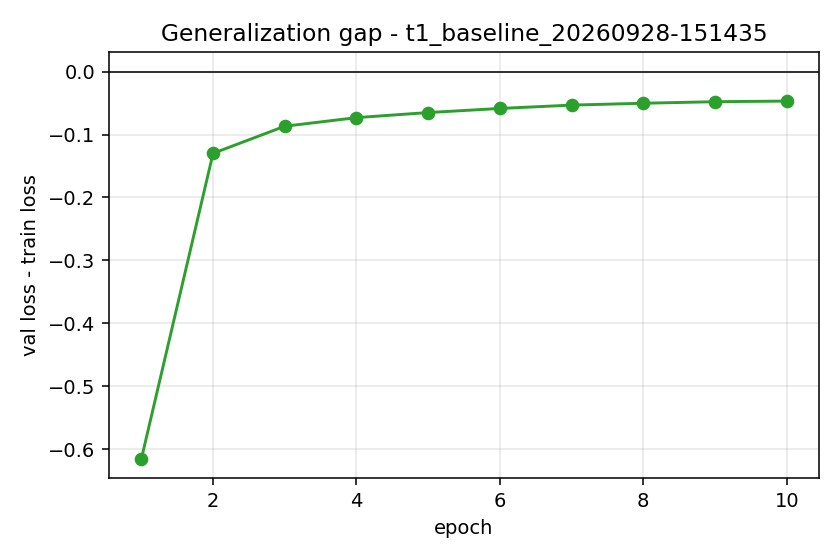

In [9]:
from IPython.display import Image, display
display(Image(filename=str(MEMBER/f'outputs/plots/loss_curves_{RUN}.png')))
display(Image(filename=str(MEMBER/f'outputs/plots/generalization_gap_{RUN}.png')))

In [10]:
gn = hist['grad_norms']; sl = hist['step_losses']
print('steps: %d | grad norm mean %.4f max %.4f' % (len(gn), np.mean(gn), np.max(gn)))
print('NaNs: %d | non-finite losses: %d' % (sum(not np.isfinite(g) for g in gn),
                                            sum(not np.isfinite(l) for l in sl)))
print('validation loss decreased every epoch:', bool((df["loss"].diff().dropna() < 0).all()))

steps: 31250 | grad norm mean 0.7491 max 9.7431
NaNs: 0 | non-finite losses: 0
validation loss decreased every epoch: True


## 5. Text generation

Greedy and temperature sampling, 3 prompts x 3 strategies.

In [11]:
print((MEMBER/f'outputs/samples/samples_{RUN}.txt').read_text()[:1500])

### greedy | prompt='Once upon a time'
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine and explore the world. One day, she went to the park with her mommy and daddy. Lily was so excited to see her mommy and daddy. 
As they were walking, Lily saw a big box of colors and she saw a big box of colors. She wanted to see what was inside. She wanted to see what was inside. She took a big bite of the colors and 

### temperature=0.8 | prompt='Once upon a time'
Once upon a time, there was a boy named Timmy. Timmy loved to play in the snow, eat cookies for his long teddy every day.
One day, Timmy wanted to find a new friend, so he asked his mom what he wanted to do. Timmy's mom said yes, but he was a little bit scared. Timmy wanted to make something very happy and be a little bit strong and slowly.
Timmy put the bitter in a blue frog and he never forgot the frog. He felt

### temperature=1.2 | prompt='Once upon a time'
Once upon a time, there was a

In [12]:
from evaluate import distinct_n, repeated_ngram_rate
import re
blocks = re.split(r'### ', (MEMBER/f'outputs/samples/samples_{RUN}.txt').read_text())[1:]
groups = {}
for b in blocks:
    head, body = b.split('\n', 1)
    groups.setdefault(head.split(' | ')[0].strip(), []).append(body)
rows = [{'strategy': k, 'distinct_1': distinct_n('\n'.join(v),1), 'distinct_2': distinct_n('\n'.join(v),2),
         'distinct_3': distinct_n('\n'.join(v),3), 'repeated_4gram': repeated_ngram_rate('\n'.join(v),4)}
        for k, v in groups.items()]
pd.DataFrame(rows).round(4)

,strategy,distinct_1,distinct_2,distinct_3,repeated_4gram
0,greedy,0.0263,0.1442,0.2648,0.6488
1,temperature=0.8,0.0295,0.2016,0.4195,0.4206
2,temperature=1.2,0.0359,0.2346,0.5511,0.2478


## 6. All required metrics

Each run writes **both** tables: `metrics_report.csv` in the team-agreed column schema (so my
numbers line up with my teammate's) and `metrics_report_extended.csv` with the columns the team
header omits. Both writers reject a row missing a required column, so neither can silently drop
a metric.

In [13]:
team = pd.read_csv(MEMBER/'metrics_report.csv')          # team-agreed schema
ext  = pd.read_csv(MEMBER/'metrics_report_extended.csv')  # my full set
print('team schema columns: %d | extended: %d' % (len(team.columns), len(ext.columns)))
print('in extended but not in the team header (renames + genuine extras):')
print(' ', sorted(set(ext.columns) - set(team.columns)))
row = ext[ext.run_id == RUN].T
row.columns = ['value']
row

team schema columns: 22 | extended: 25
in extended but not in the team header (renames + genuine extras):
  ['bits_per_char', 'checkpoint_id', 'config_path', 'device', 'model_name', 'param_count', 'top1_next_char_acc', 'total_train_seconds', 'train_loss', 'val_loss']


,value
run_id,t1_baseline_20260928-151435
model_name,t1_baseline
config_path,task1_llm/zoheb_waghu/configs/gpt_baseline.yaml
checkpoint_id,t1_baseline_20260928-151435_best.pt
train_loss,0.69909
val_loss,0.70286
perplexity,2.0195
bits_per_char,1.01401
generalization_gap,0.00377
top1_next_char_acc,0.77719


## 7. Failure analysis (2 marks)

Three cases with the verbatim generated text, failure type and observation:
[failure_analysis.md](failure_analysis.md).

1. **Phrase-level repetition loop** under greedy - repeated-4-gram rate 0.6488 vs 0.2478 at temperature 1.2
2. **Locally fluent but semantically impossible** text - `put the bitter in a blue frog`, `lots of spicy fox one knife`
3. **Story-boundary confusion** - the model abandons the current story and restarts with `Once upon a time`

At 256x the training data the invalid-word failure of my first run is gone, but repetition got
*worse* (0.5319 -> 0.6488): a more confident model follows greedy's argmax into loops more
readily, not less.

Full write-up and design justification: [results.md](results.md).